<a href="https://colab.research.google.com/github/FrancescoRito/WEC_analysis_notebook/blob/main/WEC_Analysis_freepractice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

#Read the Excel file, specifying the dtype for the 'NUMBER' column as string
#!!INSERT THE CSV PATH HERE!!
df_fp = pd.read_csv(filepath_or_buffer='/content/23_Analysis_Free Practice 2.csv',sep=';', dtype={'NUMBER': str})

#Remove potential leading spaces
df_fp.columns = df_fp.columns.str.strip()

#Subset the DataFrame to include only the needed columns
df_fp = df_fp[["NUMBER","LAP_NUMBER","LAP_TIME","FLAG_AT_FL","PIT_TIME","TEAM","MANUFACTURER","CLASS","DRIVER_NAME","S1_SECONDS","S2_SECONDS","S3_SECONDS"]]


#Rename the 'NUMBER' column to 'CAR_NUMBER' for better clarity
df_fp = df_fp.rename(columns={'NUMBER': 'CAR_NUMBER'})

#Create 'TIME_IN_SECONDS' column: sum of S1, S2, S3 sector times (rounded to 3 decimals).
df_fp["TIME_IN_SECONDS"] = round(df_fp["S1_SECONDS"] + df_fp["S2_SECONDS"] + df_fp["S3_SECONDS"],3)

#Create a combined 'TEAM_NUMBER' string (e.g., "TeamName - CarNumber") for data visualization labels.
df_fp["TEAM_NUMBER"] = df_fp["TEAM"]+' - '+df_fp["CAR_NUMBER"]

#Remove rows with missing sector times (NaN in S1/S2/S3) to prevent issues from potentially incomplete/corrupt source file.
df_fp = df_fp.dropna(subset=['S1_SECONDS', 'S2_SECONDS', 'S3_SECONDS'])

df_fp

,CAR_NUMBER,LAP_NUMBER,LAP_TIME,FLAG_AT_FL,PIT_TIME,TEAM,MANUFACTURER,CLASS,DRIVER_NAME,S1_SECONDS,S2_SECONDS,S3_SECONDS,TIME_IN_SECONDS,TEAM_NUMBER
0,007,1,4:02.898,GF,0:01:56.110,Aston Martin Thor Team,Aston Martin,HYPERCAR,Harry TINCKNELL,148.060,41.809,53.029,242.898,Aston Martin Thor Team - 007
1,007,2,1:46.045,GF,NaN,Aston Martin Thor Team,Aston Martin,HYPERCAR,Harry TINCKNELL,21.741,34.940,49.364,106.045,Aston Martin Thor Team - 007
2,007,3,1:36.832,GF,NaN,Aston Martin Thor Team,Aston Martin,HYPERCAR,Harry TINCKNELL,20.455,31.805,44.572,96.832,Aston Martin Thor Team - 007
3,007,4,1:34.534,GF,NaN,Aston Martin Thor Team,Aston Martin,HYPERCAR,Harry TINCKNELL,19.566,30.735,44.233,94.534,Aston Martin Thor Team - 007
4,007,5,1:34.523,GF,NaN,Aston Martin Thor Team,Aston Martin,HYPERCAR,Harry TINCKNELL,19.225,30.872,44.426,94.523,Aston Martin Thor Team - 007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1635,99,44,1:35.208,GF,NaN,Proton Competition,Porsche,HYPERCAR,Nicolas PINO,19.338,31.143,44.727,95.208,Proton Competition - 99
1636,99,45,1:35.830,GF,NaN,Proton Competition,Porsche,HYPERCAR,Nicolas PINO,19.540,31.809,44.481,95.830,Proton Competition - 99
1637,99,46,1:36.636,GF,NaN,Proton Competition,Porsche,HYPERCAR,Nicolas PINO,19.557,32.435,44.644,96.636,Proton Competition - 99
1638,99,47,1:35.593,GF,NaN,Proton Competition,Porsche,HYPERCAR,Nicolas PINO,19.414,31.159,45.020,95.593,Proton Competition - 99


In [ ]:
#Filter for HYPERCAR class entries into a new DataFrame.
df_hypercar_fp = df_fp[(df_fp['CLASS'] == 'HYPERCAR')]


#Filter for LMGT3 class entries into a new DataFrame.
df_lmgt3_fp = df_fp[(df_fp['CLASS'] == 'LMGT3')]

In [ ]:
#Function to manage boxplot creation and display
def boxplot_to_chart(df_to_boxplot):

     #Get the unique team - car identifiers ('TEAM_NUMBER') from the input DataFrame.
    single_label = df_to_boxplot["TEAM_NUMBER"].unique()

    #Calculate the median lap time for each unique team - car to determine sorting order.
    mediam_times = [] # This remains a list to store median values.
    for car in single_label:
        median_time = df_to_boxplot['TIME_IN_SECONDS'][df_to_boxplot['TEAM_NUMBER'] == car].median() # Calculate median and store in a separate variable
        mediam_times.append(median_time) # Append the calculated median to the list

    #Determine the sorting order based on the calculated median times (fastest first).
    sorted_indices = np.argsort(mediam_times)

    #Reorder the team/car labels according to the sorted indices.
    sorted_labels = single_label[sorted_indices]

    #Create a list of lap time data Series, ordered according to the sorted team - car labels.
    #This structure is often required by plotting functions like plt.boxplot().
    sorted_data = [df_to_boxplot['TIME_IN_SECONDS'][df_to_boxplot['TEAM_NUMBER'] == car] for car in sorted_labels]

    return sorted_labels, sorted_data

In [ ]:
#Function to manage heatmap creation and display
def heatmap_to_chart(df_to_heatmap):

  #Calculate median lap time per team
  median_team = df_to_heatmap.groupby('TEAM_NUMBER')['TIME_IN_SECONDS'].median()

  #Sort team - car by speed (fastest first).
  ordine_team = median_team.sort_values().index

  #Create the pivot table for the heatmap's underlying numeric values.
  pivot_values = df_to_heatmap.pivot(index='TEAM_NUMBER', columns='LAP_NUMBER', values='TIME_IN_SECONDS').loc[ordine_team]

  #Create the pivot table for the heatmap's cell annotations (labels).
  pivot_labels = df_to_heatmap.pivot(index='TEAM_NUMBER', columns='LAP_NUMBER', values='LAP_TIME').loc[ordine_team]

  return pivot_labels, pivot_values

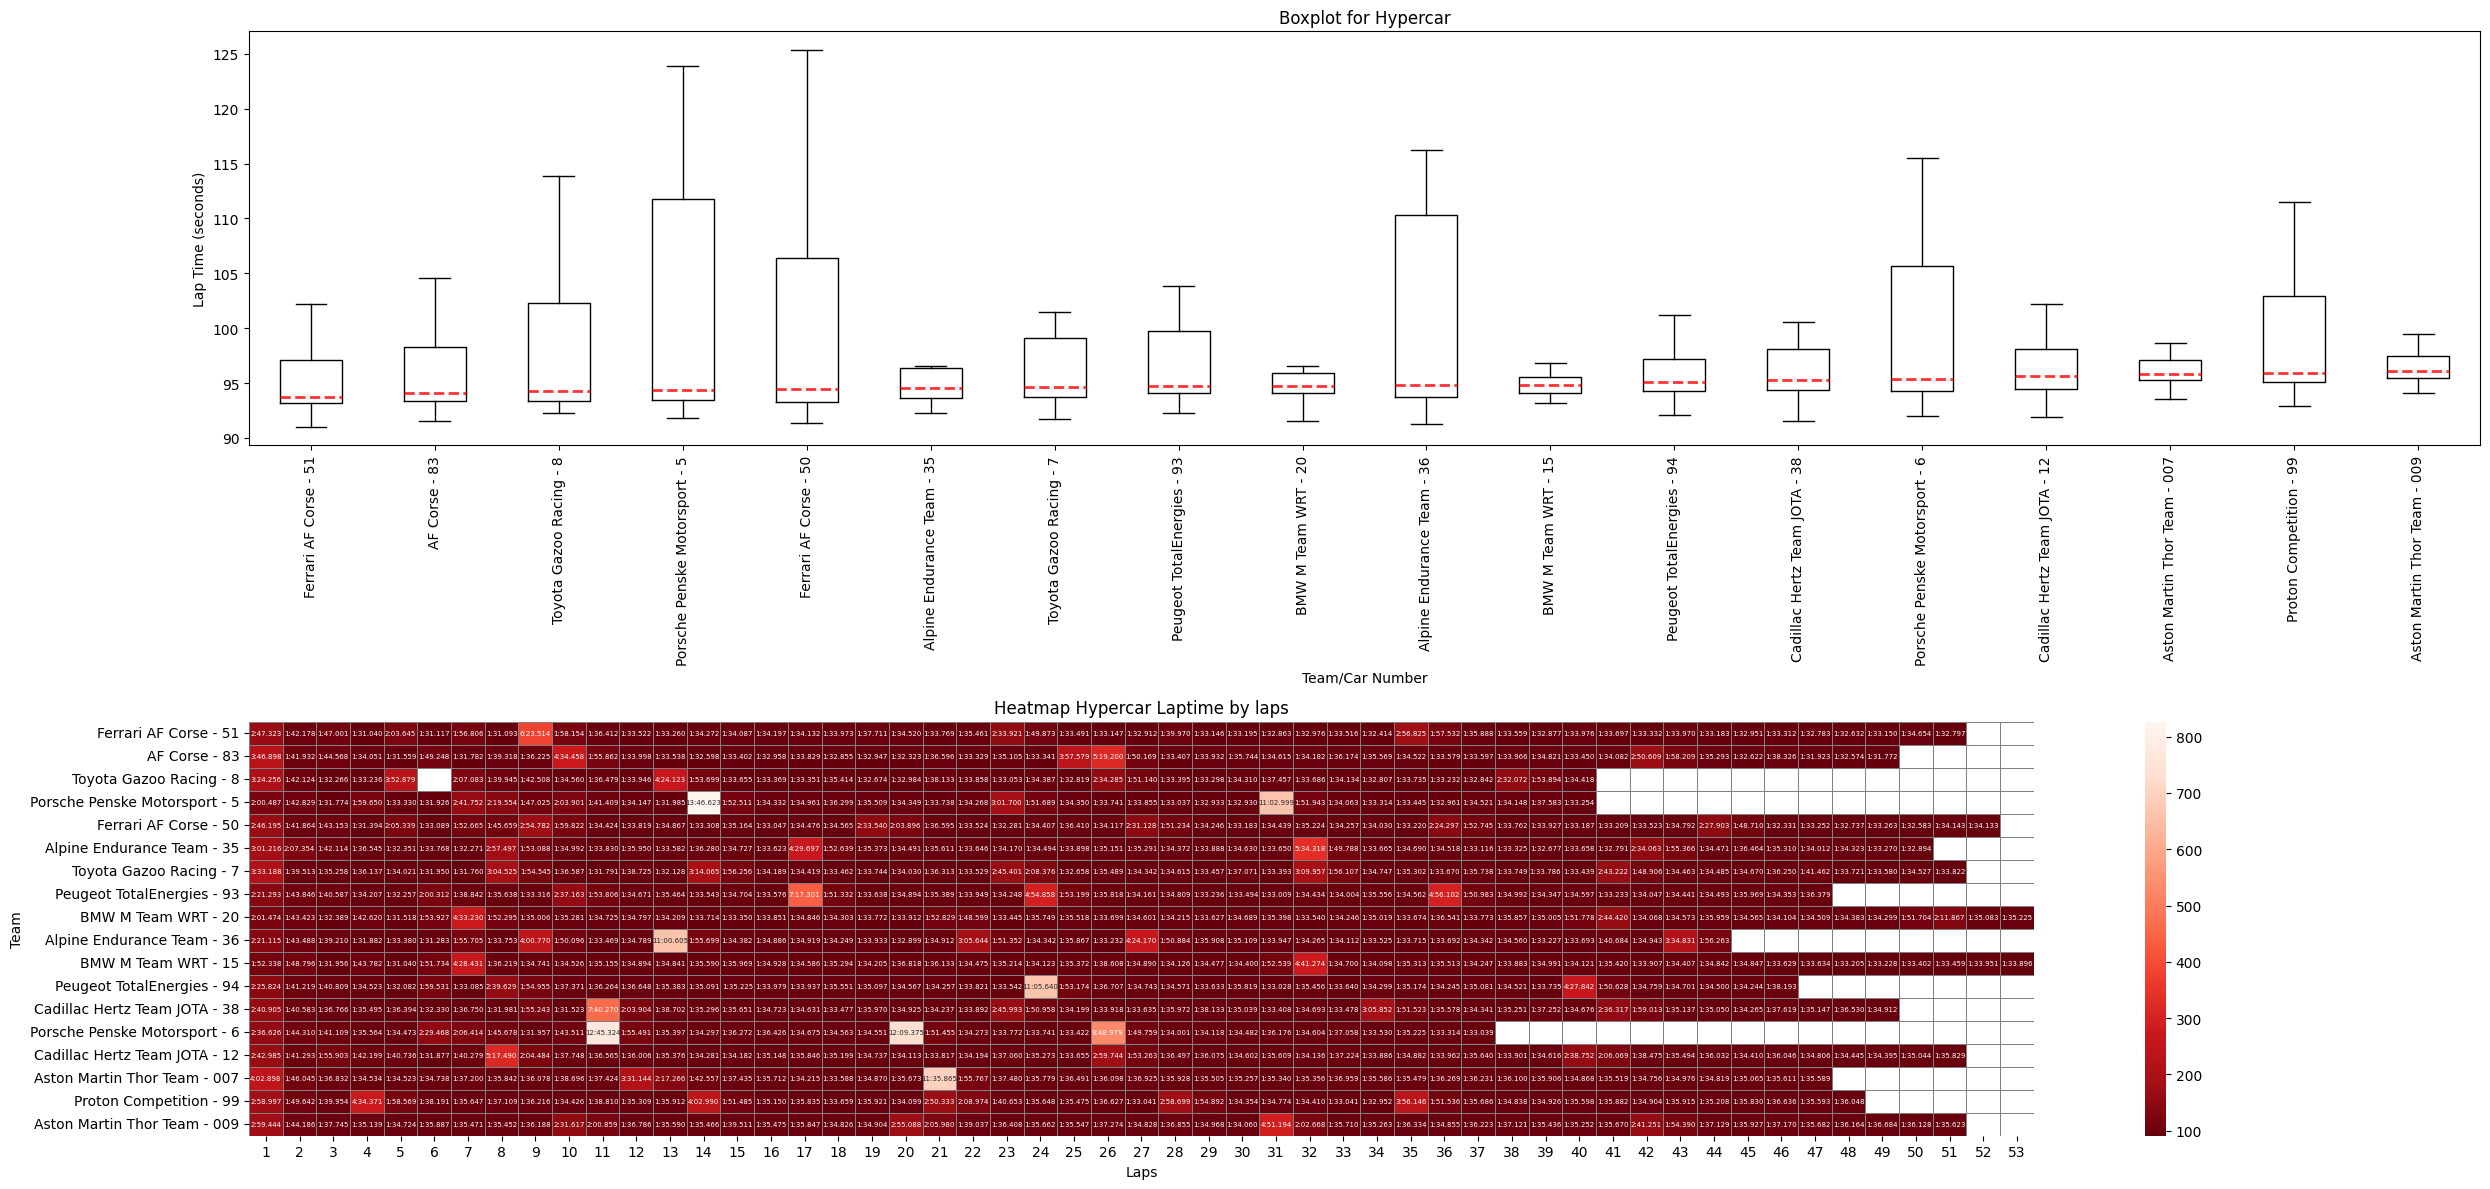

In [ ]:
#HYPERCAR
#Create two vertically stacked subplots
fig, axs = plt.subplots(2, 1, figsize=(25, 12))  #2 rows, 1 column

#Prepare sorted labels and data required for the HYPERCAR class boxplot using the custom function.
sorted_labels_boxplot_hc, sorted_data_boxplot_hc = boxplot_to_chart(df_hypercar_fp)

#Prepare the sorted data structure required for the HYPERCAR class race heatmap using the custom function.
sorted_labels_heat_hc, sorted_data_heat_hc = heatmap_to_chart(df_hypercar_fp)

#First subplot [Boxplot]
axs[0].boxplot(sorted_data_boxplot_hc, showfliers=False, tick_labels=sorted_labels_boxplot_hc,medianprops=dict(color='red', linewidth=2, linestyle='--', alpha=0.8))
axs[0].set_xlabel('Team/Car Number')
axs[0].set_ylabel('Lap Time (seconds)')
axs[0].set_title('Boxplot for Hypercar')
axs[0].tick_params(axis='x', rotation=90)

#Second subplot [Heatmap]
sns.heatmap(
    sorted_data_heat_hc,
    cmap='Reds_r',
    annot=sorted_labels_heat_hc, #Use the custom labels from 'sorted_labels_heat_hc' for cell annotations.
    fmt="",
    annot_kws={"size": 5},
    cbar=True,
    linewidths=0.5,
    linecolor='gray',
    ax=axs[1]  #Specify the axes object (the second subplot) to draw this plot on
)
axs[1].set_title('Heatmap Hypercar Laptime by laps')
axs[1].set_xlabel('Laps')
axs[1].set_ylabel('Team')

#Adjust layout to prevent overlapping elements.
plt.tight_layout()

plt.show()

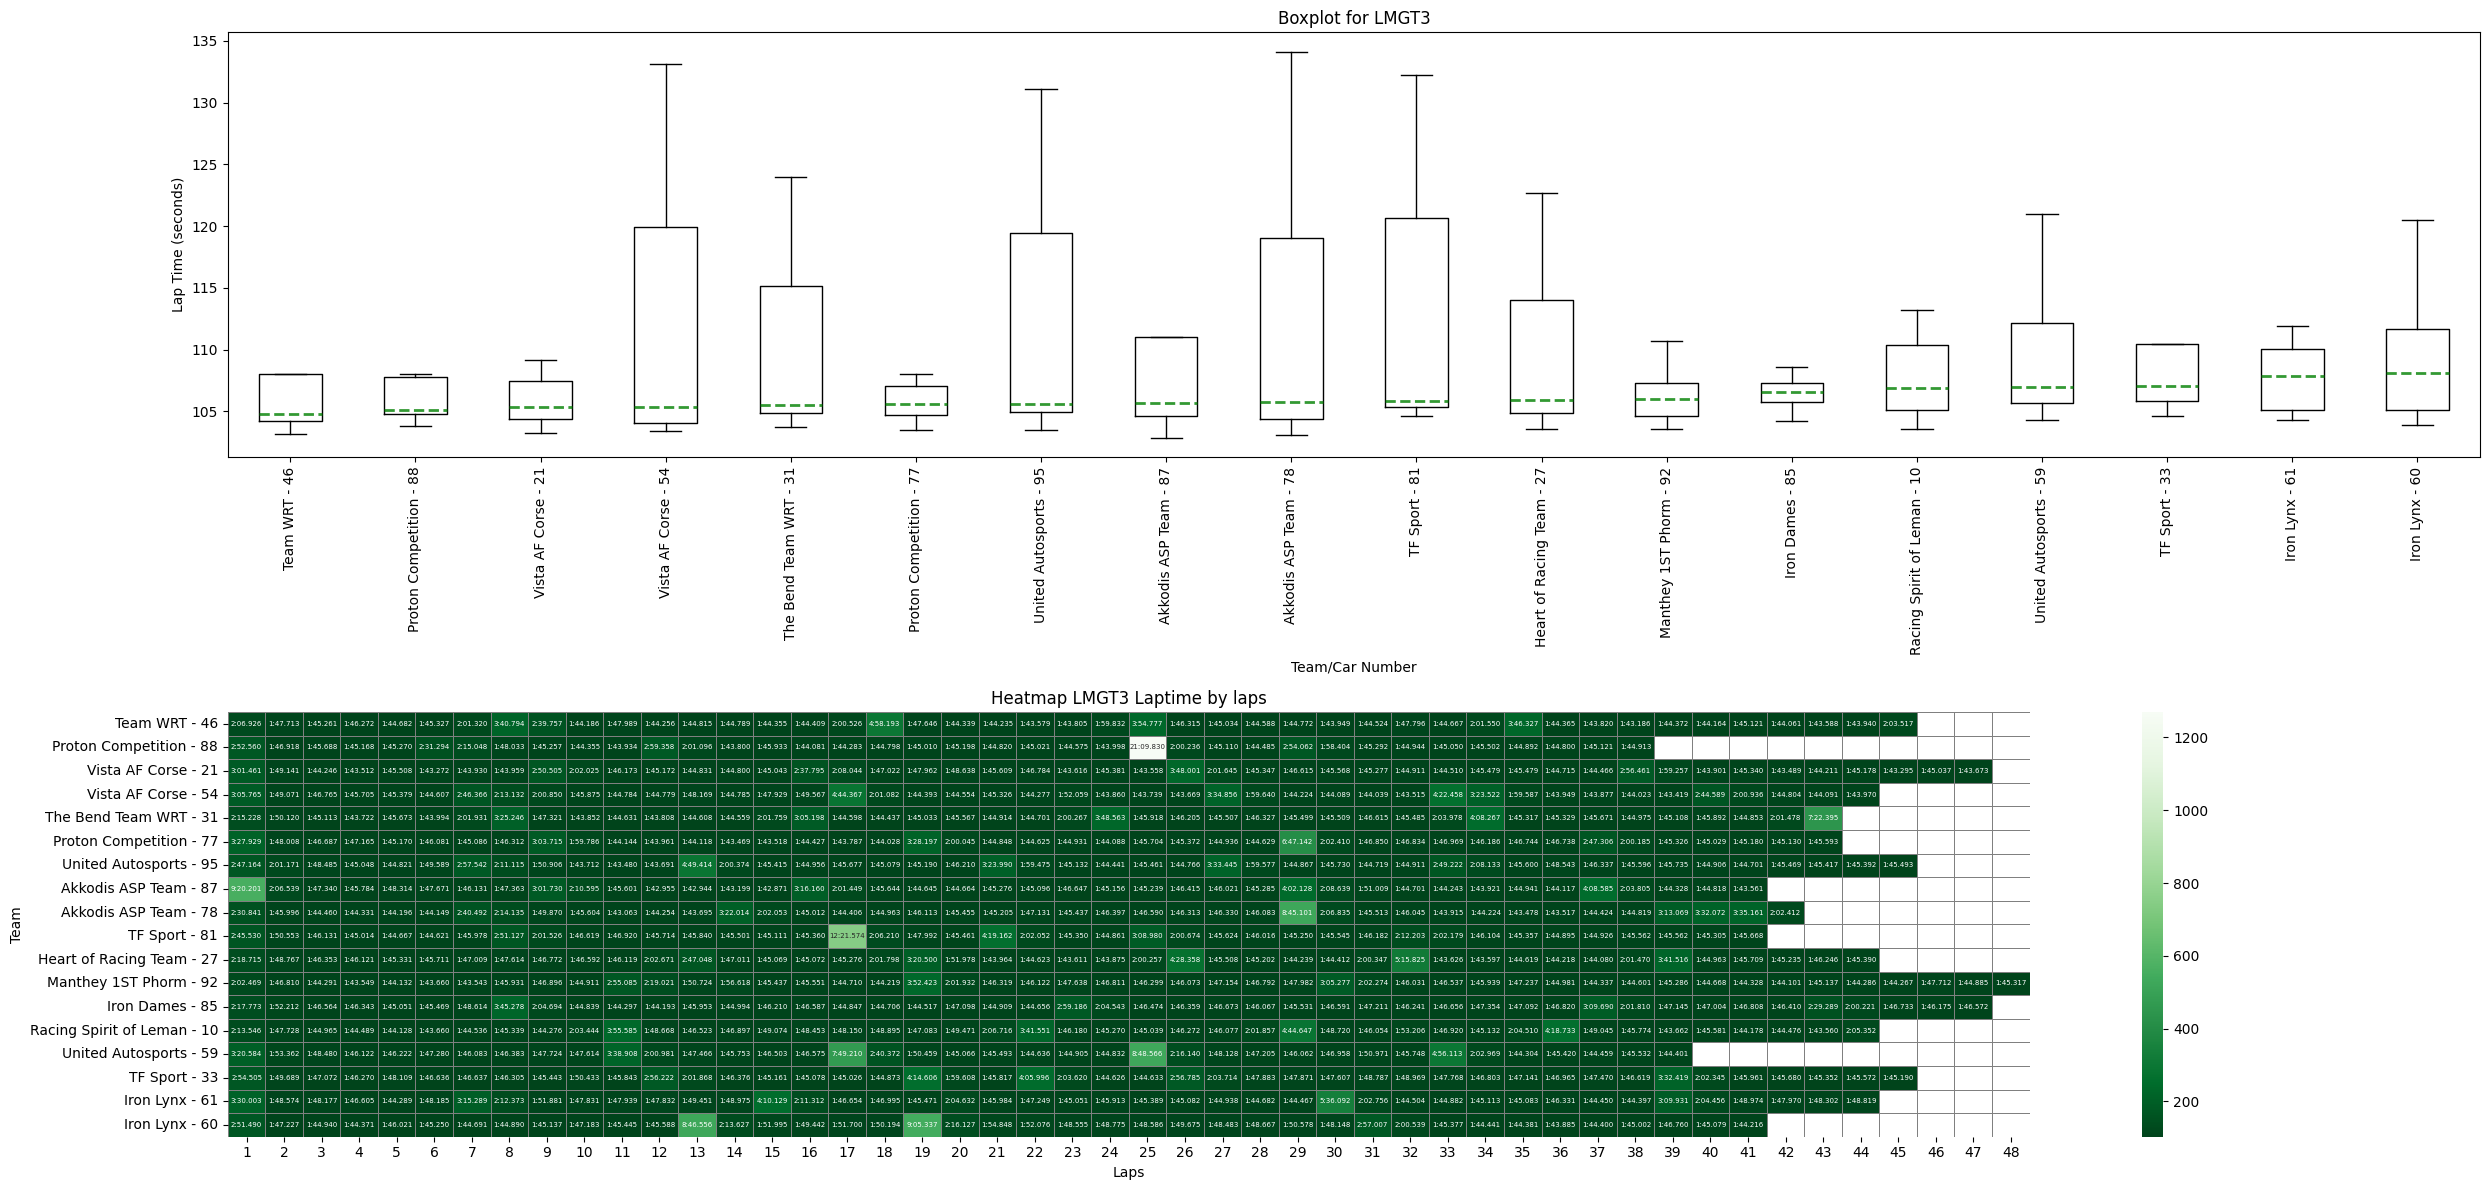

In [ ]:
#LMGT3
#Create two vertically stacked subplots
fig, axs = plt.subplots(2, 1, figsize=(25, 12))  # 2 rows, 1 column

#Prepare sorted labels and data required for the LMGT3 class boxplot using the custom function.
sorted_labels_boxplot_hc, sorted_data_boxplot_hc = boxplot_to_chart(df_lmgt3_fp)

#Prepare the sorted data structure required for the LMGT3 class race heatmap using the custom function.
sorted_labels_heat_hc, sorted_data_heat_hc = heatmap_to_chart(df_lmgt3_fp)

#First subplot [Boxplot]
axs[0].boxplot(sorted_data_boxplot_hc, showfliers=False, tick_labels=sorted_labels_boxplot_hc,medianprops=dict(color='green', linewidth=2, linestyle='--', alpha=0.8))
axs[0].set_xlabel('Team/Car Number')
axs[0].set_ylabel('Lap Time (seconds)')
axs[0].set_title('Boxplot for LMGT3')
axs[0].tick_params(axis='x', rotation=90)

#Second subplot [Heatmap]
sns.heatmap(
    sorted_data_heat_hc,
    cmap='Greens_r',
    annot=sorted_labels_heat_hc, #Use the custom labels from 'sorted_labels_heat_hc' for cell annotations.
    fmt="",
    annot_kws={"size": 5},
    cbar=True,
    linewidths=0.5,
    linecolor='gray',
    ax=axs[1]  #Specify the axes object (the second subplot) to draw this plot on
)
axs[1].set_title('Heatmap LMGT3 Laptime by laps')
axs[1].set_xlabel('Laps')
axs[1].set_ylabel('Team')

#Adjust layout to prevent overlapping elements.
plt.tight_layout()

plt.show()